# 📊 Dataset Information

**Note:** The dataset for this project is **not included in this repository** to keep the repository lightweight.  

You can download the dataset from **Kaggle** using the link below:  

[Download The Superstore Sales Sample Dataset](https://www.kaggle.com/datasets/divyjain28/superstore-sales)  

Please make sure to place the downloaded CSV file in the same directory as this notebook before running any code.

# Importing

## Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

/kaggle/input/datasets/divyjain28/superstore-sales/sample_-_superstore.csv
/kaggle/input/datasets/divyjain28/superstore-sales/sample_-_superstore.xls


## Import CSV And convert to DataFrame

In [2]:
df = pd.read_csv('sample_-_superstore.csv')

# Preprocessing

## Frist five row

In [3]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,US-2023-103800,01/03/2023,01/07/2023,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,...,77095,Central,OFF-PA-10000174,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.448,2,0.2,5.5512
1,2,US-2023-112326,01/04/2023,01/08/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-BI-10004094,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.540,2,0.8,-5.4870
2,3,US-2023-112326,01/04/2023,01/08/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-LA-10003223,Office Supplies,Labels,Avery 508,11.784,3,0.2,4.2717
3,4,US-2023-112326,01/04/2023,01/08/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,272.736,3,0.2,-64.7748
4,5,US-2023-141817,01/05/2023,01/12/2023,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,...,19143,East,OFF-AR-10003478,Office Supplies,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.536,3,0.2,4.8840


## last Five row

In [4]:
df.tail()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
10189,10190,US-2026-143259,12/30/2026,01/03/2027,Standard Class,PO-18865,Patrick O'Donnell,Consumer,United States,New York City,...,10009,East,OFF-BI-10003684,Office Supplies,Binders,Wilson Jones Legal Size Ring Binders,52.776,3,0.2,19.7910
10190,10191,US-2026-115427,12/30/2026,01/03/2027,Standard Class,EB-13975,Erica Bern,Corporate,United States,Fairfield,...,94533,West,OFF-BI-10004632,Office Supplies,Binders,GBC Binding covers,20.720,2,0.2,6.4750
10191,10192,US-2026-156720,12/30/2026,01/03/2027,Standard Class,JM-15580,Jill Matthias,Consumer,United States,Loveland,...,80538,West,OFF-FA-10003472,Office Supplies,Fasteners,Bagged Rubber Bands,3.024,3,0.2,-0.6048
10192,10193,US-2026-143259,12/30/2026,01/03/2027,Standard Class,PO-18865,Patrick O'Donnell,Consumer,United States,New York City,...,10009,East,TEC-PH-10004774,Technology,Phones,Gear Head AU3700S Headset,90.930,7,0.0,2.7279
10193,10194,CA-2026-143500,12/30/2026,01/03/2027,Standard Class,HO-15230,Harry Olson,Consumer,Canada,Charlottetown,...,C0A,East,OFF-BI-10004040,Office Supplies,Binders,Wilson Jones Impact Binders,3.024,3,0.2,-0.6048


## Shape of our dataset

In [5]:
df.shape

(10194, 21)

## List out all columns

In [6]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country/Region', 'City',
       'State/Province', 'Postal Code', 'Region', 'Product ID', 'Category',
       'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount',
       'Profit'],
      dtype='object')

## Datatype of each columns

In [7]:
df.dtypes

Row ID              int64
Order ID           object
Order Date         object
Ship Date          object
Ship Mode          object
Customer ID        object
Customer Name      object
Segment            object
Country/Region     object
City               object
State/Province     object
Postal Code        object
Region             object
Product ID         object
Category           object
Sub-Category       object
Product Name       object
Sales             float64
Quantity            int64
Discount          float64
Profit            float64
dtype: object

## Information of all Columns

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          10194 non-null  int64  
 1   Order ID        10194 non-null  object 
 2   Order Date      10194 non-null  object 
 3   Ship Date       10194 non-null  object 
 4   Ship Mode       10194 non-null  object 
 5   Customer ID     10194 non-null  object 
 6   Customer Name   10194 non-null  object 
 7   Segment         10194 non-null  object 
 8   Country/Region  10194 non-null  object 
 9   City            10194 non-null  object 
 10  State/Province  10194 non-null  object 
 11  Postal Code     10194 non-null  object 
 12  Region          10194 non-null  object 
 13  Product ID      10194 non-null  object 
 14  Category        10194 non-null  object 
 15  Sub-Category    10194 non-null  object 
 16  Product Name    10194 non-null  object 
 17  Sales           10194 non-null 

## Check Null Value

In [9]:
df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country/Region    0
City              0
State/Province    0
Postal Code       0
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Quantity          0
Discount          0
Profit            0
dtype: int64

## Check Dupicate Value

In [10]:
df.duplicated().sum()

np.int64(0)

## Summary

In [11]:
df.describe()

,Row ID,Sales,Quantity,Discount,Profit
count,10194.000000,10194.000000,10194.000000,10194.000000,10194.000000
mean,5097.500000,228.225854,3.791838,0.155385,28.673417
std,2942.898656,619.906839,2.228317,0.206249,232.465115
min,1.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2549.250000,17.220000,2.000000,0.000000,1.760800
50%,5097.500000,53.910000,3.000000,0.200000,8.690000
75%,7645.750000,209.500000,5.000000,0.200000,29.297925
max,10194.000000,22638.480000,14.000000,0.800000,8399.976000


# EDA

In [12]:
def show_fig():
    plt.tight_layout()
    plt.show()

plot_no = 1

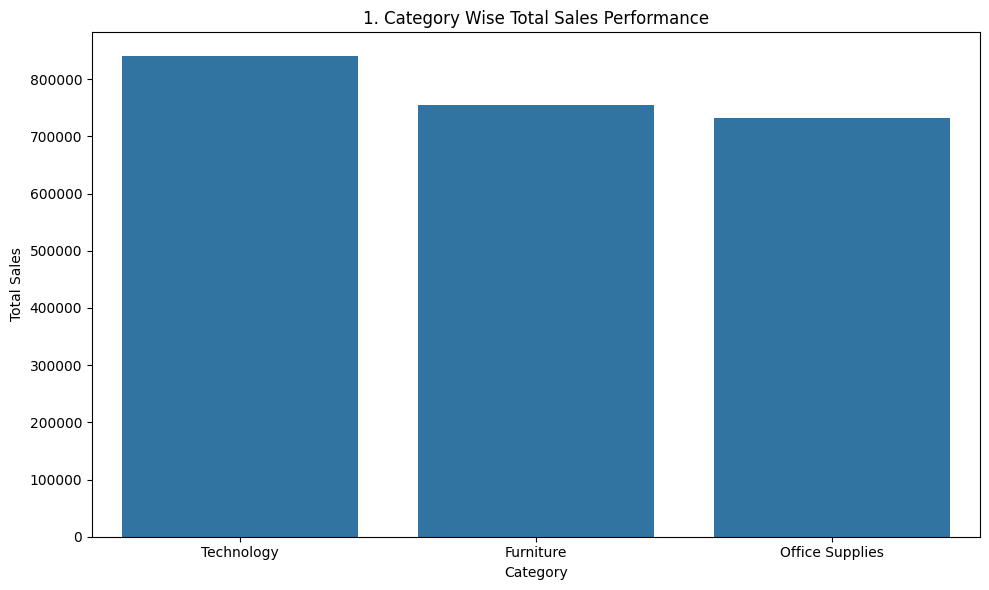

In [13]:
top_category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

fig = plt.figure(figsize=(10,6))
sns.barplot(x=top_category_sales.index, y=top_category_sales.values)
plt.title(f'{plot_no}. Category Wise Total Sales Performance')
plt.xlabel('Category')
plt.ylabel('Total Sales')
show_fig()
plot_no += 1

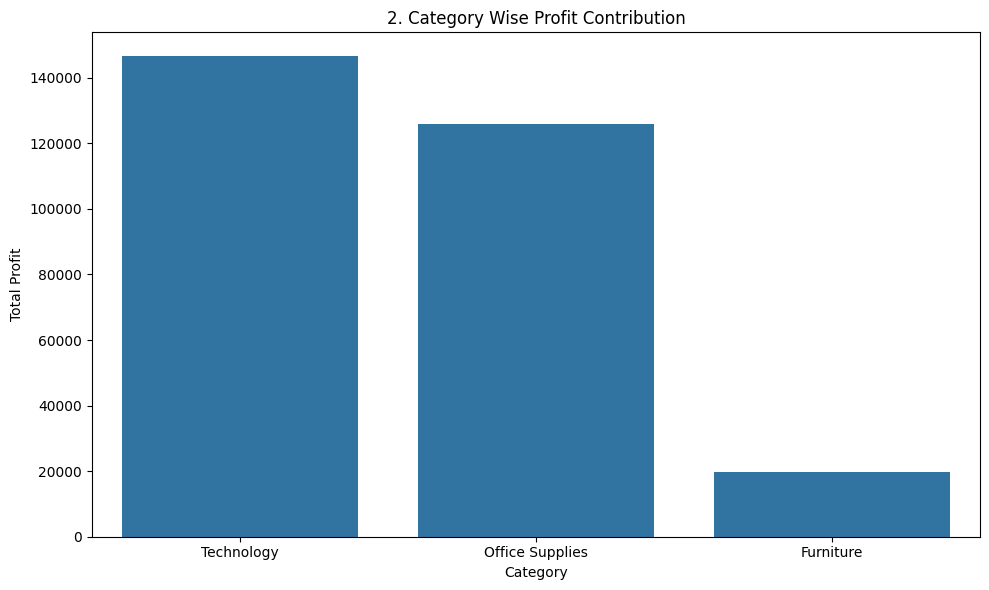

In [14]:
top_category_profit = df.groupby('Category')['Profit'].sum().sort_values(ascending=False)

fig = plt.figure(figsize=(10,6))
sns.barplot(x=top_category_profit.index, y=top_category_profit.values)
plt.title(f'{plot_no}. Category Wise Profit Contribution')
plt.xlabel('Category')
plt.ylabel('Total Profit')
show_fig()
plot_no += 1

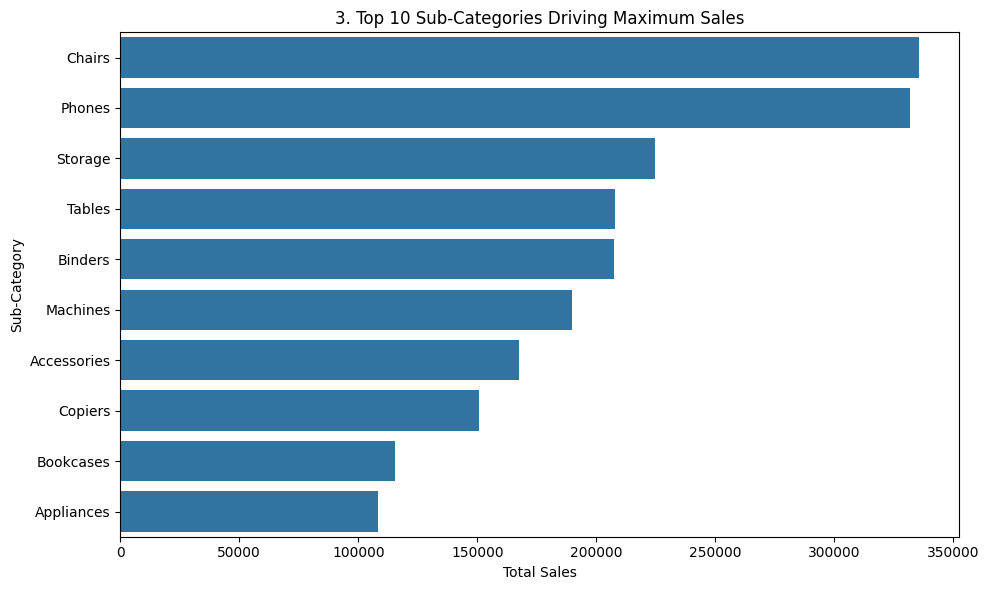

In [15]:
subcat_sales = df.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=False).head(10)

fig = plt.figure(figsize=(10,6))
sns.barplot(x=subcat_sales.values, y=subcat_sales.index)
plt.title(f'{plot_no}. Top 10 Sub-Categories Driving Maximum Sales')
plt.xlabel('Total Sales')
plt.ylabel('Sub-Category')
show_fig()
plot_no += 1

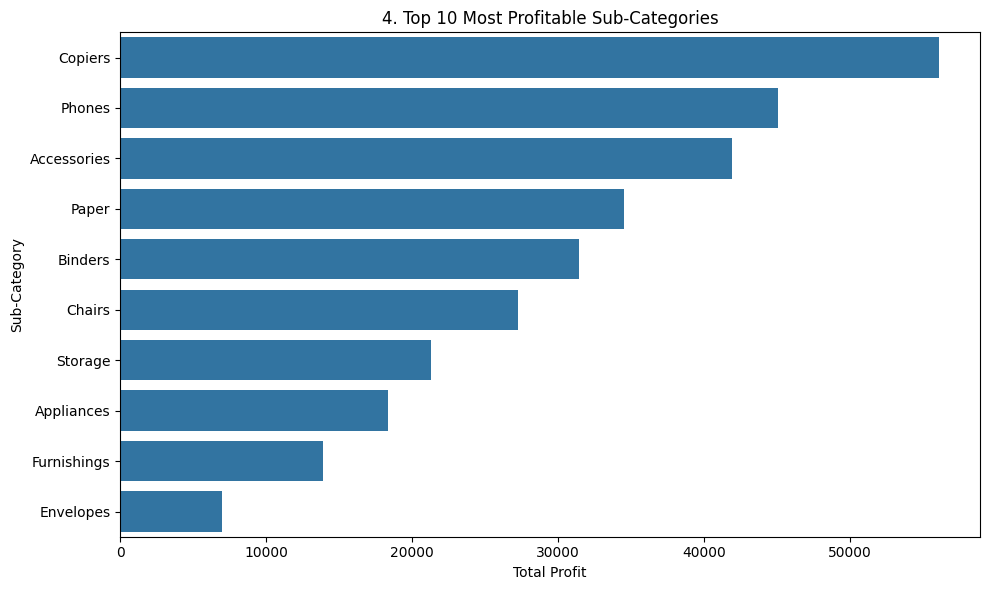

In [16]:
subcat_profit = df.groupby('Sub-Category')['Profit'].sum().sort_values(ascending=False).head(10)

fig = plt.figure(figsize=(10,6))
sns.barplot(x=subcat_profit.values, y=subcat_profit.index)
plt.title(f'{plot_no}. Top 10 Most Profitable Sub-Categories')
plt.xlabel('Total Profit')
plt.ylabel('Sub-Category')
show_fig()
plot_no += 1

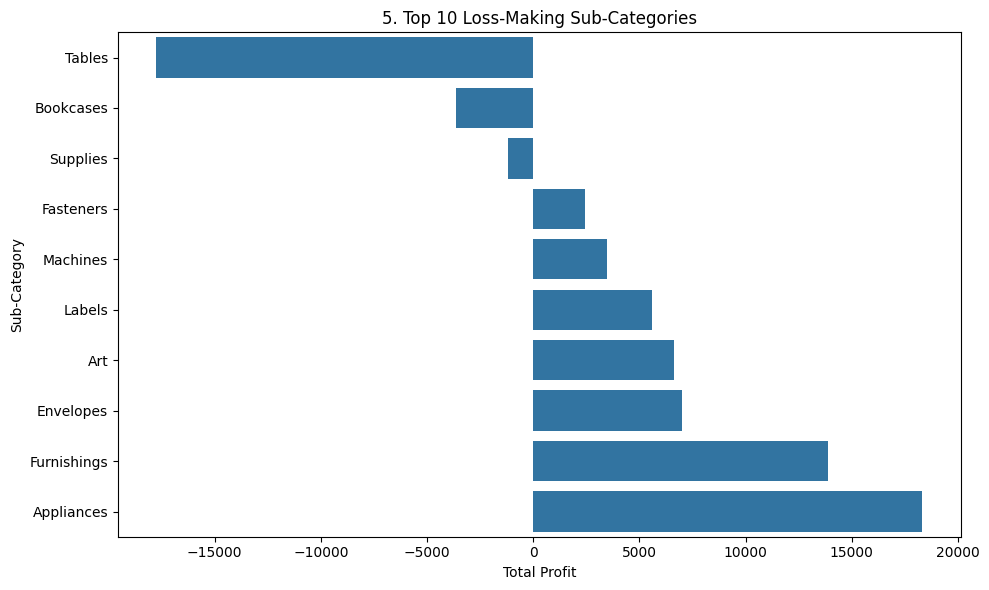

In [17]:
subcat_loss = df.groupby('Sub-Category')['Profit'].sum().sort_values().head(10)

fig = plt.figure(figsize=(10,6))
sns.barplot(x=subcat_loss.values, y=subcat_loss.index)
plt.title(f'{plot_no}. Top 10 Loss-Making Sub-Categories')
plt.xlabel('Total Profit')
plt.ylabel('Sub-Category')
show_fig()
plot_no += 1

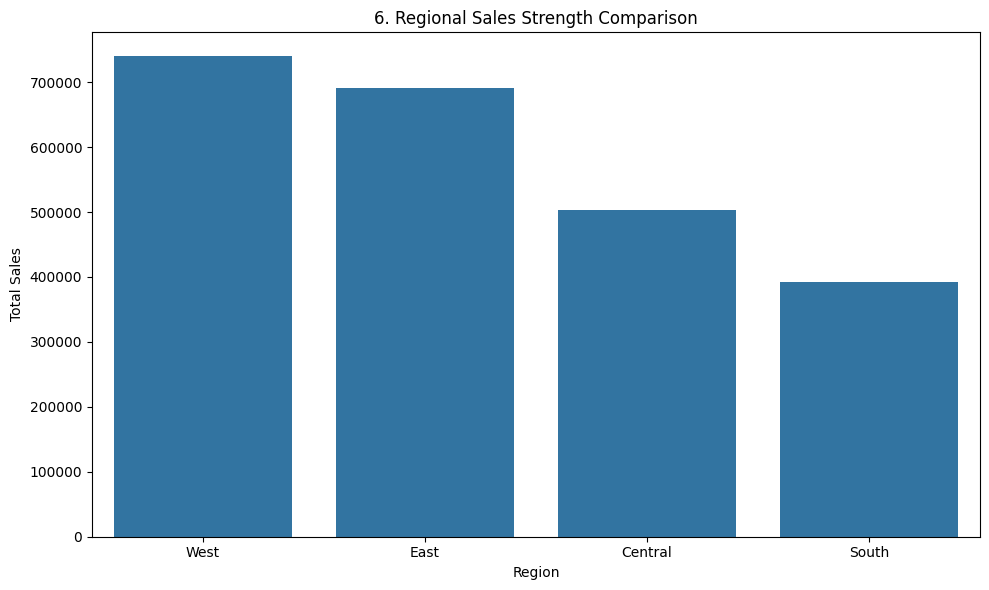

In [18]:
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)

fig = plt.figure(figsize=(10,6))
sns.barplot(x=region_sales.index, y=region_sales.values)
plt.title(f'{plot_no}. Regional Sales Strength Comparison')
plt.xlabel('Region')
plt.ylabel('Total Sales')
show_fig()
plot_no += 1

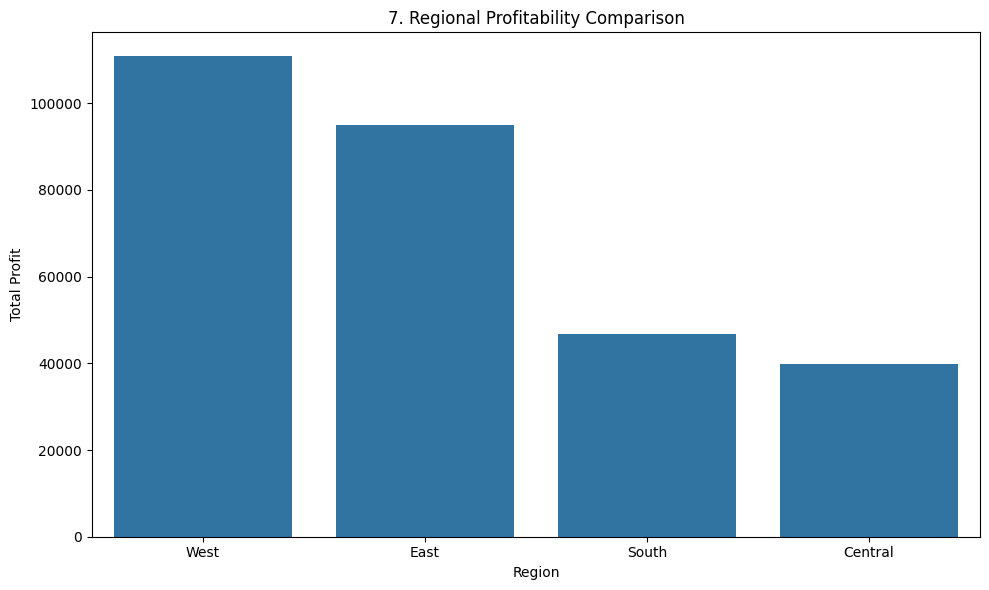

In [19]:
region_profit = df.groupby('Region')['Profit'].sum().sort_values(ascending=False)

fig = plt.figure(figsize=(10,6))
sns.barplot(x=region_profit.index, y=region_profit.values)
plt.title(f'{plot_no}. Regional Profitability Comparison')
plt.xlabel('Region')
plt.ylabel('Total Profit')
show_fig()
plot_no += 1

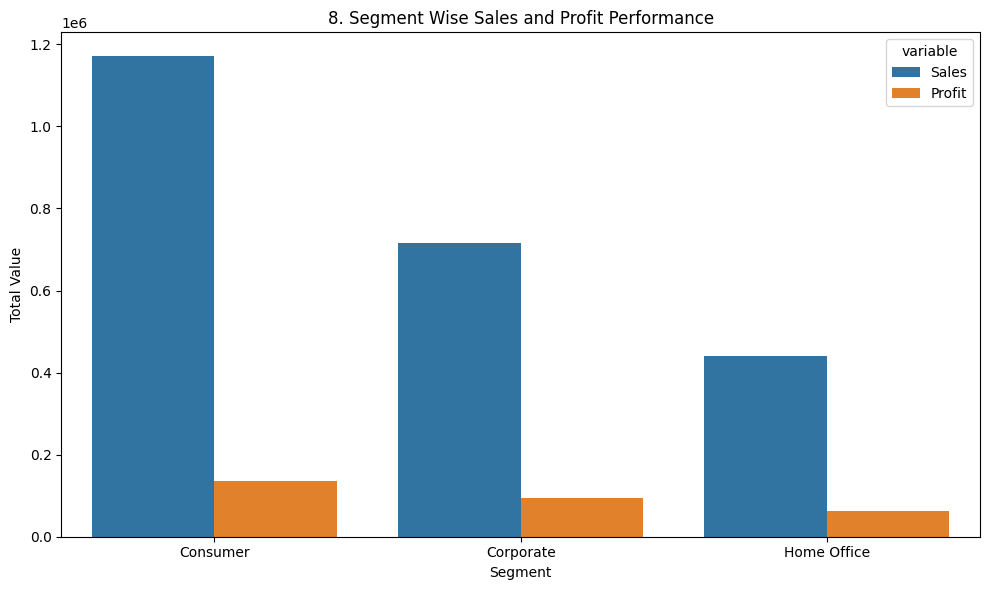

In [20]:
segment_sales_profit = df.groupby('Segment')[['Sales', 'Profit']].sum().reset_index()

fig = plt.figure(figsize=(10,6))
segment_sales_profit_melted = segment_sales_profit.melt(id_vars='Segment', value_vars=['Sales', 'Profit'])
sns.barplot(data=segment_sales_profit_melted, x='Segment', y='value', hue='variable')
plt.title(f'{plot_no}. Segment Wise Sales and Profit Performance')
plt.xlabel('Segment')
plt.ylabel('Total Value')
show_fig()
plot_no += 1

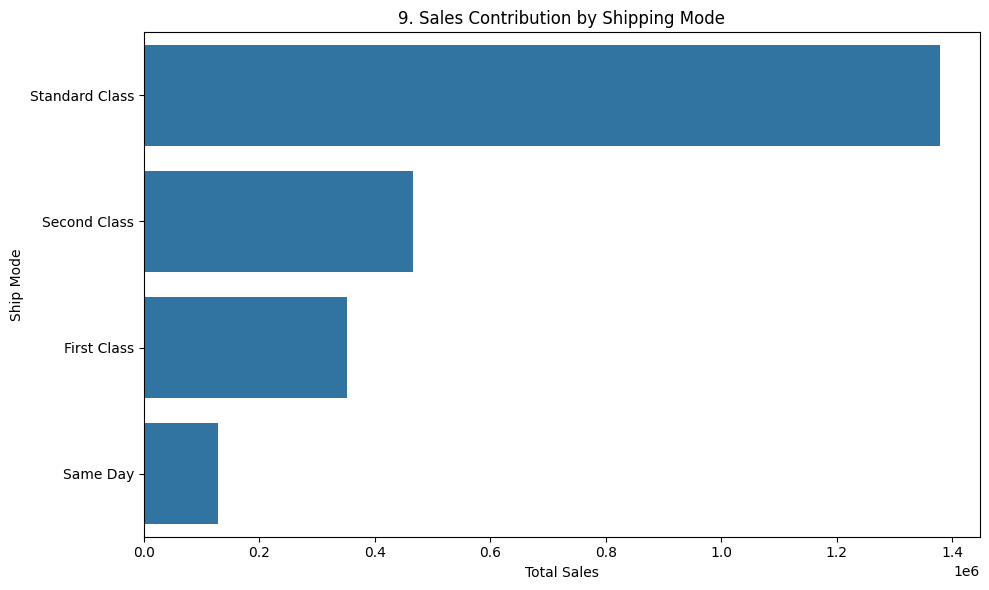

In [21]:
shipmode_sales = df.groupby('Ship Mode')['Sales'].sum().sort_values(ascending=False)

fig = plt.figure(figsize=(10,6))
sns.barplot(x=shipmode_sales.values, y=shipmode_sales.index)
plt.title(f'{plot_no}. Sales Contribution by Shipping Mode')
plt.xlabel('Total Sales')
plt.ylabel('Ship Mode')
show_fig()
plot_no += 1

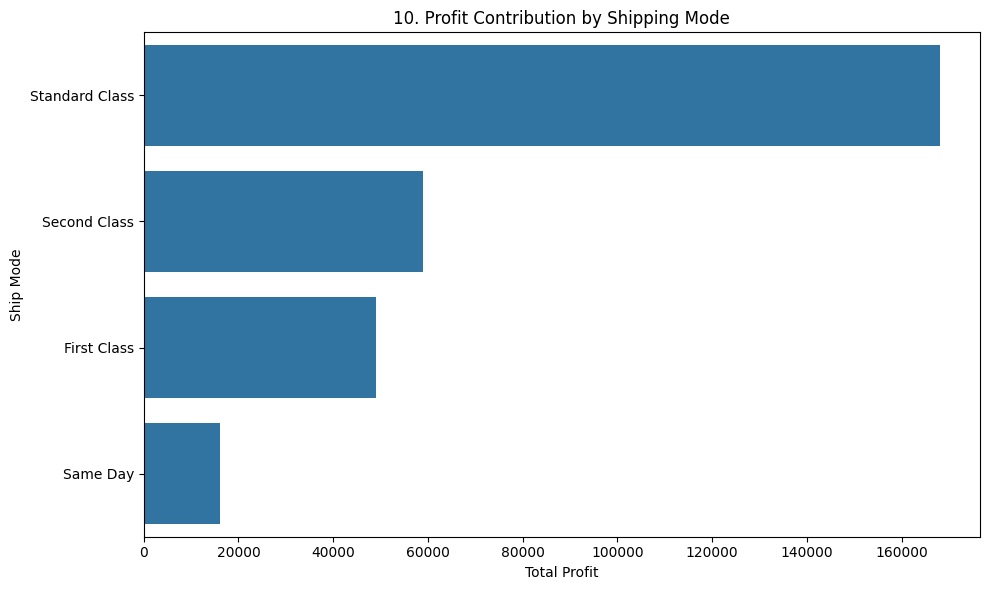

In [22]:
shipmode_profit = df.groupby('Ship Mode')['Profit'].sum().sort_values(ascending=False)

fig = plt.figure(figsize=(10,6))
sns.barplot(x=shipmode_profit.values, y=shipmode_profit.index)
plt.title(f'{plot_no}. Profit Contribution by Shipping Mode')
plt.xlabel('Total Profit')
plt.ylabel('Ship Mode')
show_fig()
plot_no += 1

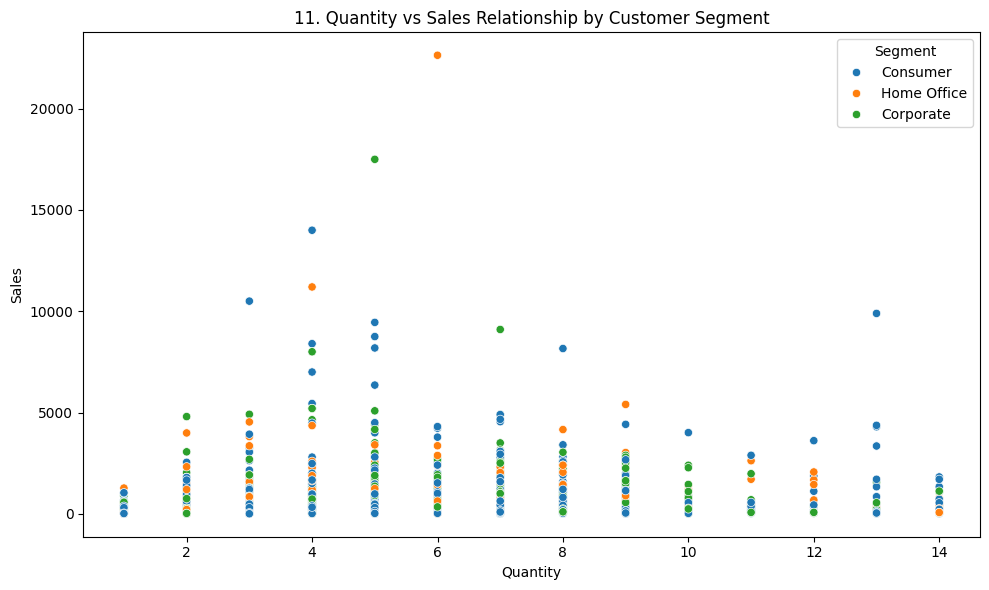

In [23]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Quantity', y='Sales', hue='Segment')
plt.title(f'{plot_no}. Quantity vs Sales Relationship by Customer Segment')
plt.xlabel('Quantity')
plt.ylabel('Sales')
show_fig()
plot_no += 1

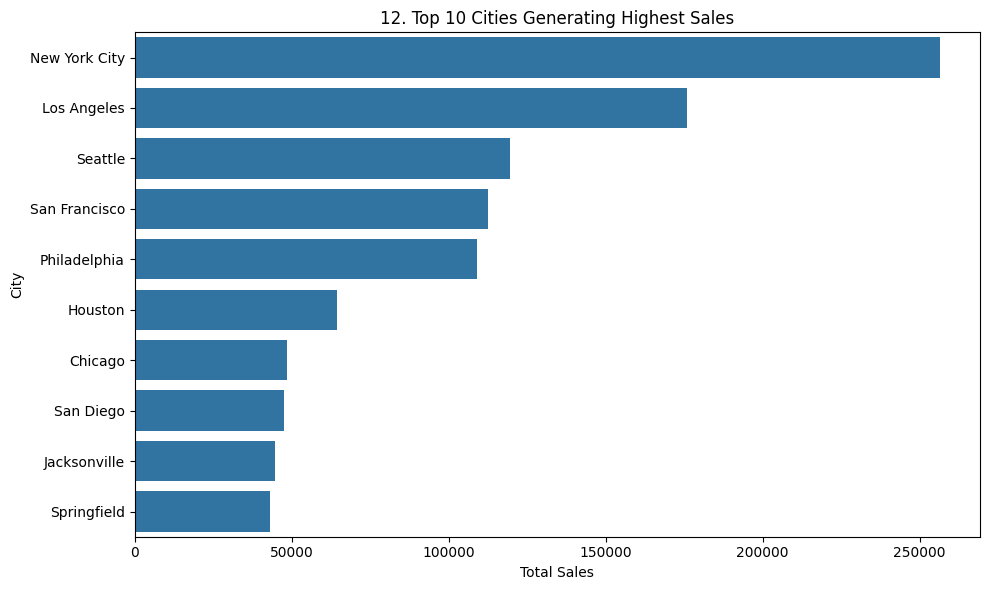

In [24]:
city_sales = df.groupby('City')['Sales'].sum().sort_values(ascending=False).head(10)

fig = plt.figure(figsize=(10,6))
sns.barplot(x=city_sales.values, y=city_sales.index)
plt.title(f'{plot_no}. Top 10 Cities Generating Highest Sales')
plt.xlabel('Total Sales')
plt.ylabel('City')
show_fig()
plot_no += 1

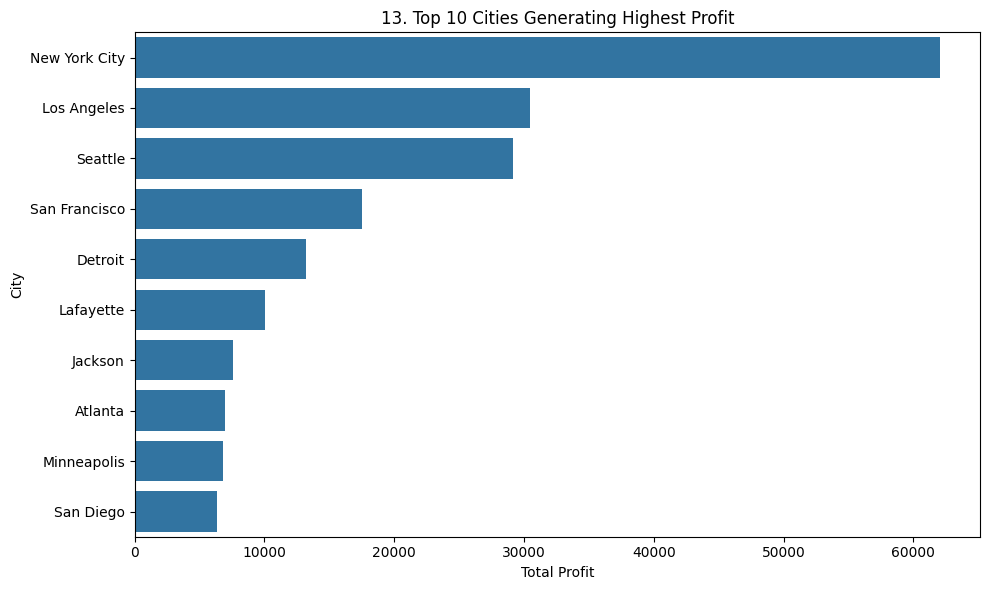

In [25]:
city_profit = df.groupby('City')['Profit'].sum().sort_values(ascending=False).head(10)

fig = plt.figure(figsize=(10,6))
sns.barplot(x=city_profit.values, y=city_profit.index)
plt.title(f'{plot_no}. Top 10 Cities Generating Highest Profit')
plt.xlabel('Total Profit')
plt.ylabel('City')
show_fig()
plot_no += 1

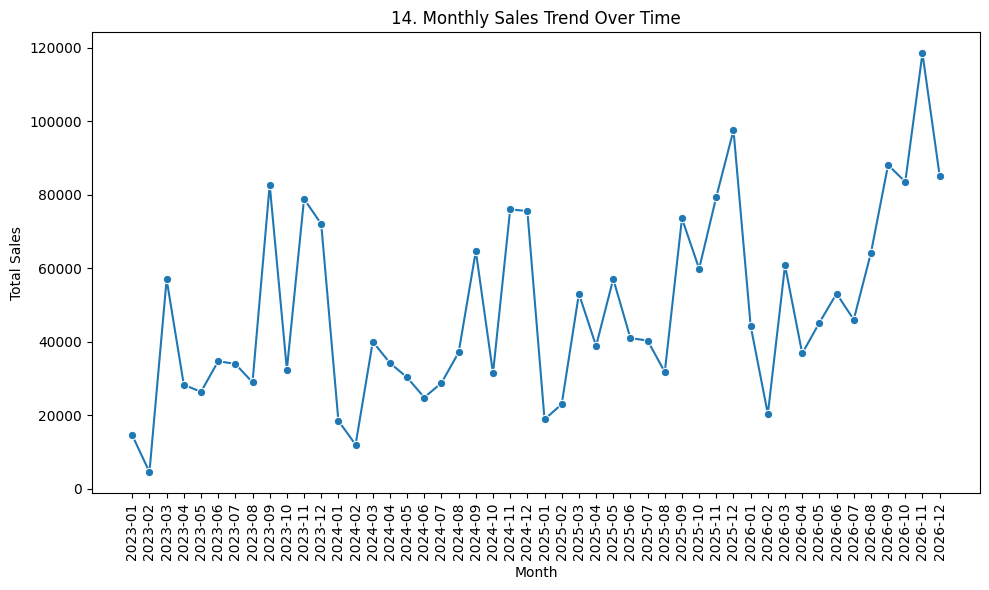

In [26]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
monthly_sales = df.groupby(df['Order Date'].dt.to_period('M'))['Sales'].sum()
monthly_sales.index = monthly_sales.index.astype(str)

fig = plt.figure(figsize=(10,6))
sns.lineplot(x=monthly_sales.index, y=monthly_sales.values, marker='o')
plt.title(f'{plot_no}. Monthly Sales Trend Over Time')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(rotation=90)
show_fig()
plot_no += 1

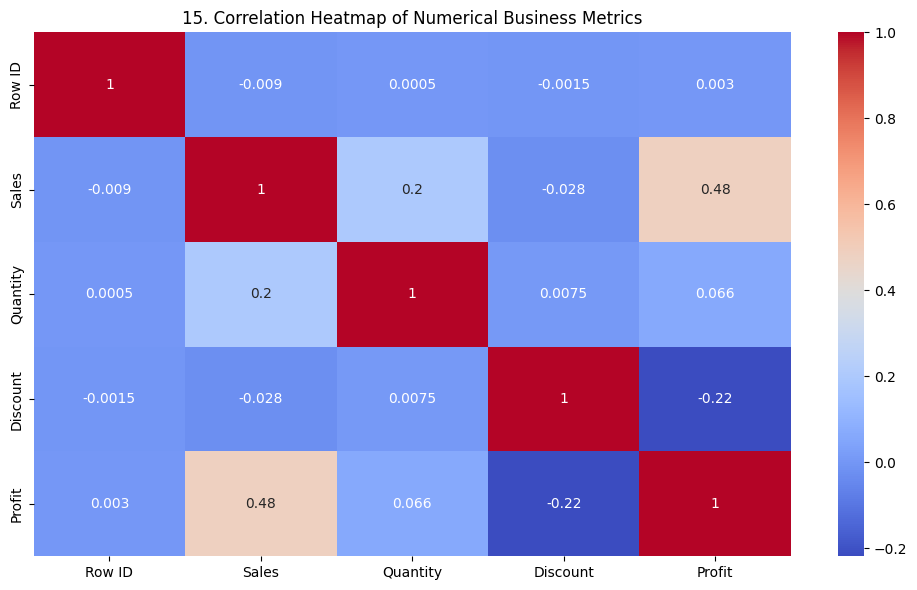

In [27]:
corr = df.select_dtypes(include='number').corr()

fig = plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title(f'{plot_no}. Correlation Heatmap of Numerical Business Metrics')
show_fig()
plot_no += 1

# Model Trainnig

## Copy dataframe

In [28]:
data = df.copy()

## Convert date columns

In [29]:
data['Order Date'] = pd.to_datetime(data['Order Date'], errors='coerce')
data['Ship Date'] = pd.to_datetime(data['Ship Date'], errors='coerce')

## Create useful date features

In [30]:
data['Order_Year'] = data['Order Date'].dt.year
data['Order_Month'] = data['Order Date'].dt.month
data['Order_Day'] = data['Order Date'].dt.day
data['Ship_Year'] = data['Ship Date'].dt.year
data['Ship_Month'] = data['Ship Date'].dt.month
data['Ship_Day'] = data['Ship Date'].dt.day
data['Shipping_Days'] = (data['Ship Date'] - data['Order Date']).dt.days

## Remove outliers using IQR method

In [31]:
outlier_cols = ['Sales', 'Quantity', 'Discount', 'Profit']

for col in outlier_cols:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    data = data[(data[col] >= lower_limit) & (data[col] <= upper_limit)]

## Print rows after outlier removal

In [32]:
print("Rows after removing outliers:", data.shape[0])

Rows after removing outliers: 6892


## Drop original date and ID columns

In [33]:
drop_cols = ['Profit', 'Order Date', 'Ship Date', 'Row ID', 'Order ID', 'Customer ID', 'Customer Name', 'Product ID', 'Product Name']
X = data.drop(columns=[col for col in drop_cols if col in data.columns])
y = data['Profit']

## Detect numeric and categorical columns

In [34]:
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = X.select_dtypes(include=['object']).columns

## Preprocess numeric columns

In [35]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

## Preprocess categorical columns

In [36]:
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

## Combine preprocessing

In [37]:
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_cols),
    ('cat', categorical_transformer, categorical_cols)
])

## Create supervised regression model

In [38]:
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        random_state=42
    ))
])

## Split data into training and testing

In [39]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Train model

In [40]:
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['Sales', 'Quantity', 'Discount', 'Shipping_Days'], dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['Ship Mode', 'Segment', 'Country/Region', 'City', 'State/Province',
       'Postal Code', 'Region', 'Category', 'Sub-Category'],
      dtype='object'))])),
                ('regressor',
                 GradientBoostingRegressor(learning_rate=0.05, max_depth=4,
                                           n_estimators=300,
                                           random_state=42))])

## Predict test values

In [41]:
y_pred = model.predict(X_test)

## Print model accuracy score

In [42]:
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("Model Accuracy Score R2:", r2)
print("Mean Absolute Error:", mae)
print("Root Mean Squared Error:", rmse)

Model Accuracy Score R2: 0.7403105578871445
Mean Absolute Error: 3.6880641266303296
Root Mean Squared Error: 6.6571007781256455


## Plot actual vs predicted values

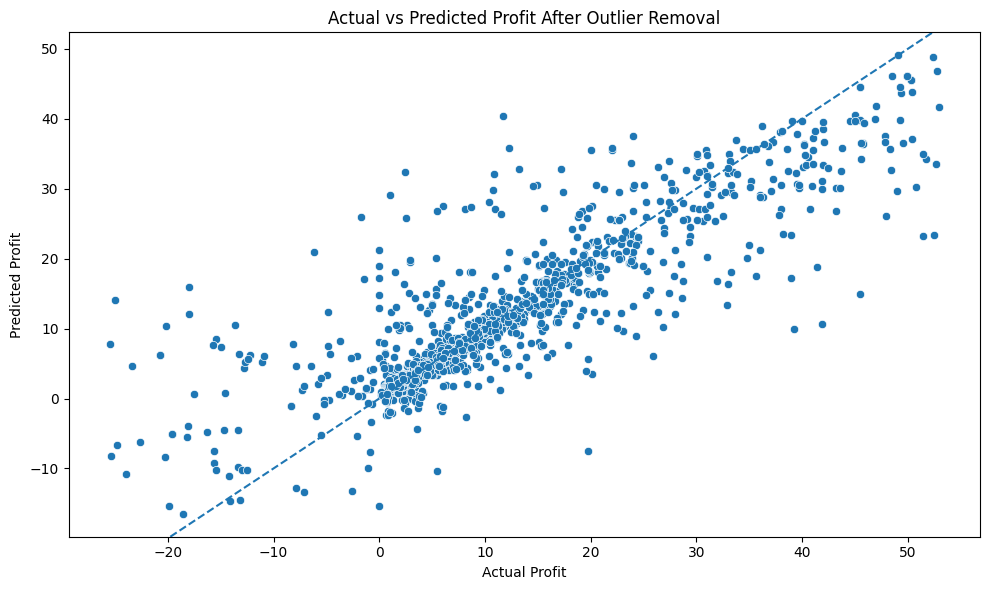

In [43]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x=y_test, y=y_pred)
plt.xlabel("Actual Profit")
plt.ylabel("Predicted Profit")
plt.title("Actual vs Predicted Profit After Outlier Removal")
plt.axline((0, 0), slope=1, linestyle="--")
plt.tight_layout()
plt.show()